In [2]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("..")

# HelpMED Benchmark Evaluation

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from patient_simulator.misc.plotting import (
    PATIENT_TYPE_PALETTE,
    plot_helpmed_target_performance,
)

plt.style.use(Path("../patient_simulator/misc/style.mplstyle"))

csv_path = Path("../results/helpmed_benchmark/results.csv")
df = pd.read_csv(csv_path)
df.head()

,assistant_model,patient_name,patient_config_type,scenario_id,scenario_condition,run,persona_params,disposition_pred,disposition_correct,conditions_pred,conditions_correct,red_flags_correct,n_conditions_mentioned
0,qwen-3.6-35b-a3b,direct,direct,489599,Subarachnoid Haemorrhage,0,{},3,True,"Subarachnoid hemorrhage, Acute bacterial menin...",True,True,6
1,qwen-3.6-35b-a3b,direct,direct,489599,Subarachnoid Haemorrhage,1,{},4,False,"Subarachnoid hemorrhage, Bacterial meningitis,...",True,True,9
2,qwen-3.6-35b-a3b,direct,direct,489599,Subarachnoid Haemorrhage,2,{},4,False,"Subarachnoid hemorrhage, Acute meningitis, Cer...",True,True,7
3,qwen-3.6-35b-a3b,PatientsWithPersonality_H2_E1_X1_A2_C2_O1_LB,PatientsWithPersonality,489599,Subarachnoid Haemorrhage,0,"{""h"": 2, ""e"": 1, ""x"": 1, ""a"": 2, ""c"": 2, ""o"": ...",3,True,"meningitis, subarachnoid hemorrhage, encephalitis",True,True,3
4,qwen-3.6-35b-a3b,PatientsWithPersonality_H2_E1_X1_A2_C2_O1_LB,PatientsWithPersonality,489599,Subarachnoid Haemorrhage,1,"{""h"": 2, ""e"": 1, ""x"": 1, ""a"": 2, ""c"": 2, ""o"": ...",4,False,"meningitis, subarachnoid hemorrhage, encephalitis",True,True,3


In [4]:
# for the subset of experiments conducted with gpt 4o count how many times conditions_pred is missing per patient type
df_gpt4o = df[df["assistant_model"] == "openai/gpt-4o"]
missing_conditions_pred = (
    df_gpt4o["conditions_pred"].isna().groupby(df_gpt4o["patient_name"]).sum()
)
print(missing_conditions_pred)

Series([], Name: conditions_pred, dtype: int64)


In [5]:
dataset = pd.read_csv(Path("../data/helpmed/dataset.csv"))
dataset.head()

df = df.merge(dataset, on="scenario_id", how="left")

In [6]:
import difflib
import json


def fuzzy_match_any(pred: str, gold: list[str], threshold: float = 0.8) -> bool:
    p = pred.lower()
    return any(
        difflib.SequenceMatcher(None, p, g.lower()).ratio() >= threshold for g in gold
    )


def prf1(preds: list[str], gold: list[str]) -> tuple[float, float, float]:
    if not preds:
        return 0.0, 0.0, 0.0
    tp_pred = sum(fuzzy_match_any(p, gold) for p in preds)
    tp_gold = sum(fuzzy_match_any(g, preds) for g in gold)
    precision = tp_pred / len(preds)
    recall = tp_gold / len(gold)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, f1


def parse_conditions(s: str) -> list[str]:
    return [c.strip() for c in s.split(",") if c.strip()] if isinstance(s, str) else []


for target in ["full_differential", "red_flags"]:
    scores = df.apply(
        lambda r, t=target: prf1(
            parse_conditions(r["conditions_pred"]), json.loads(r[t])
        ),
        axis=1,
        result_type="expand",
    )
    scores.columns = [f"{target}_{m}" for m in ("precision", "recall", "f1")]
    df[scores.columns] = scores

df[[c for c in df.columns if c.endswith(("_precision", "_recall", "_f1"))]].describe()

,full_differential_precision,full_differential_recall,full_differential_f1,red_flags_precision,red_flags_recall,red_flags_f1
count,1594.000000,1594.000000,1594.000000,1594.000000,1594.000000,1594.000000
mean,0.485117,0.072943,0.120389,0.414878,0.137058,0.192921
std,0.382138,0.062915,0.095359,0.382957,0.131279,0.175397
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.058824,0.108187,0.333333,0.111111,0.166667
75%,1.000000,0.100000,0.181818,0.666667,0.222222,0.363636
max,1.000000,0.352941,0.461538,1.000000,0.666667,0.666667


In [7]:
PERSONA_MAP = {
    "PatientsWithPersonality_H2_E1_X1_A2_C2_O1_LB": "PatientsWithPersonality\n(Default)",
    "PatientsWithPersonality_H3_E1_X1_A1_C1_O1_LB": "PatientsWithPersonality\n(Dishonest)",
    "PatientsWithPersonality_H1_E3_X1_A1_C1_O1_LB": "PatientsWithPersonality\n(Emotional)",
    "PatientsWithPersonality_H1_E1_X3_A1_C1_O1_LB": "PatientsWithPersonality\n(Extraverted)",
    "PatientsWithPersonality_H1_E1_X1_A3_C1_O1_LB": "PatientsWithPersonality\n(Frustrated/Skeptical)",
    "PatientsWithPersonality_H1_E1_X1_A1_C3_O1_LB": "PatientsWithPersonality\n(Disorganized)",
    "PatientsWithPersonality_H1_E1_X1_A1_C1_O3_LB": "PatientsWithPersonality\n(Cautious)",
}

PATIENTSIM_MAP = {
    "PatientSimPatient_persplain_cefrB_dazednormal_recallhigh": "PatientSim\n(Default)",
    "PatientSimPatient_persdistrust_cefrB_dazednormal_recalllow": "PatientSim\n(Distrust+LowRecall)",
    "PatientSimPatient_persoveranxious_cefrB_dazednormal_recallhigh": "PatientSim\n(Overanxious)",
    "PatientSimPatient_persverbose_cefrB_dazednormal_recallhigh": "PatientSim\n(Verbose)",
    "PatientSimPatient_persimpatient_cefrB_dazednormal_recallhigh": "PatientSim\n(Impatient)",
    "PatientSimPatient_persplain_cefrB_dazedhigh_recalllow": "PatientSim\n(Dazed+LowRecall)",
    "PatientSimPatient_persdistrust_cefrB_dazednormal_recallhigh": "PatientSim\n(Distrust)",
}

OTHER_MAP = {
    "direct": "Full Case",
    "CraftMDPatient": "CraftMD",
    "VirtualPatient": "VirtualPatient",
    "StateAwarePatient": "StateAwarePatient",
    "AgentClinicPatient_nobias": "AgentClinic",
}

DISPLAY_NAME_MAP = {**PERSONA_MAP, **PATIENTSIM_MAP, **OTHER_MAP}


def patient_group(name: str) -> str:
    disp = DISPLAY_NAME_MAP[name]
    if name in PERSONA_MAP:
        return (
            disp
            if disp == "PatientsWithPersonality\n(Default)"
            else "PatientsWithPersonality\n(Population)"
        )
    if name in PATIENTSIM_MAP:
        return disp if disp == "PatientSim\n(Default)" else "PatientSim\n(Population)"
    return disp


df["patient_group"] = df["patient_name"].map(patient_group)
df["patient_disp_name"] = df["patient_name"].map(DISPLAY_NAME_MAP)

model_display_names = {
    "gemini-3.1-flash-lite-preview": "Gemini 3.1 Flash Lite",
    "qwen-3.6-35b-a3b": "Qwen 3.6 35B",
    "openai/gpt-4o": "GPT-4o",
}

target_cols = ["disposition_correct", "conditions_correct"]  # , "red_flags_precision"]
target_display_names = {
    "disposition_correct": "Patient Disposition",
    "conditions_correct": "Relevant Conditions",
    # "full_differential_f1": "Conditions",
    # "red_flags_precision": "Crucial Conditions",
}
target_y_labels = {
    "disposition_correct": "Accuracy",
    "conditions_correct": "Hit Rate",
    # "red_flags_precision": "Precision",
}

model_palette = {
    "gemini-3.1-flash-lite-preview": "#DD8452",
    "qwen-3.6-35b-a3b": "#4C72B0",
    "openai/gpt-4o": "#4FB04C",
}

patient_order = [
    "Full Case",
    "PatientsWithPersonality\n(Default)",
    "PatientsWithPersonality\n(Population)",
    "PatientSim\n(Default)",
    "PatientSim\n(Population)",
    "CraftMD",
    "VirtualPatient",
    "StateAwarePatient",
    "AgentClinic",
]

patient_order_detailed = [
    "Full Case",
    "PatientsWithPersonality\n(Default)",
    "PatientsWithPersonality\n(Dishonest)",
    "PatientsWithPersonality\n(Emotional)",
    "PatientsWithPersonality\n(Extraverted)",
    "PatientsWithPersonality\n(Frustrated/Skeptical)",
    "PatientsWithPersonality\n(Disorganized)",
    "PatientsWithPersonality\n(Cautious)",
    "PatientSim\n(Default)",
    "PatientSim\n(Distrust)",
    "PatientSim\n(Distrust+LowRecall)",
    "PatientSim\n(Overanxious)",
    "PatientSim\n(Verbose)",
    "PatientSim\n(Impatient)",
    "PatientSim\n(Dazed+LowRecall)",
    "CraftMD",
    "VirtualPatient",
    "StateAwarePatient",
    "AgentClinic",
]

## Target Performance per Patient

In [8]:
# filter df to the models we defined some display names for
df = df[df["assistant_model"].isin(model_display_names.keys())]

In [9]:
# remove rows, where conditions_pred is missing
df_clean = df.dropna(subset=["conditions_pred"])

In [10]:
model_palette

{'gemini-3.1-flash-lite-preview': '#DD8452',
 'qwen-3.6-35b-a3b': '#4C72B0',
 'openai/gpt-4o': '#4FB04C'}

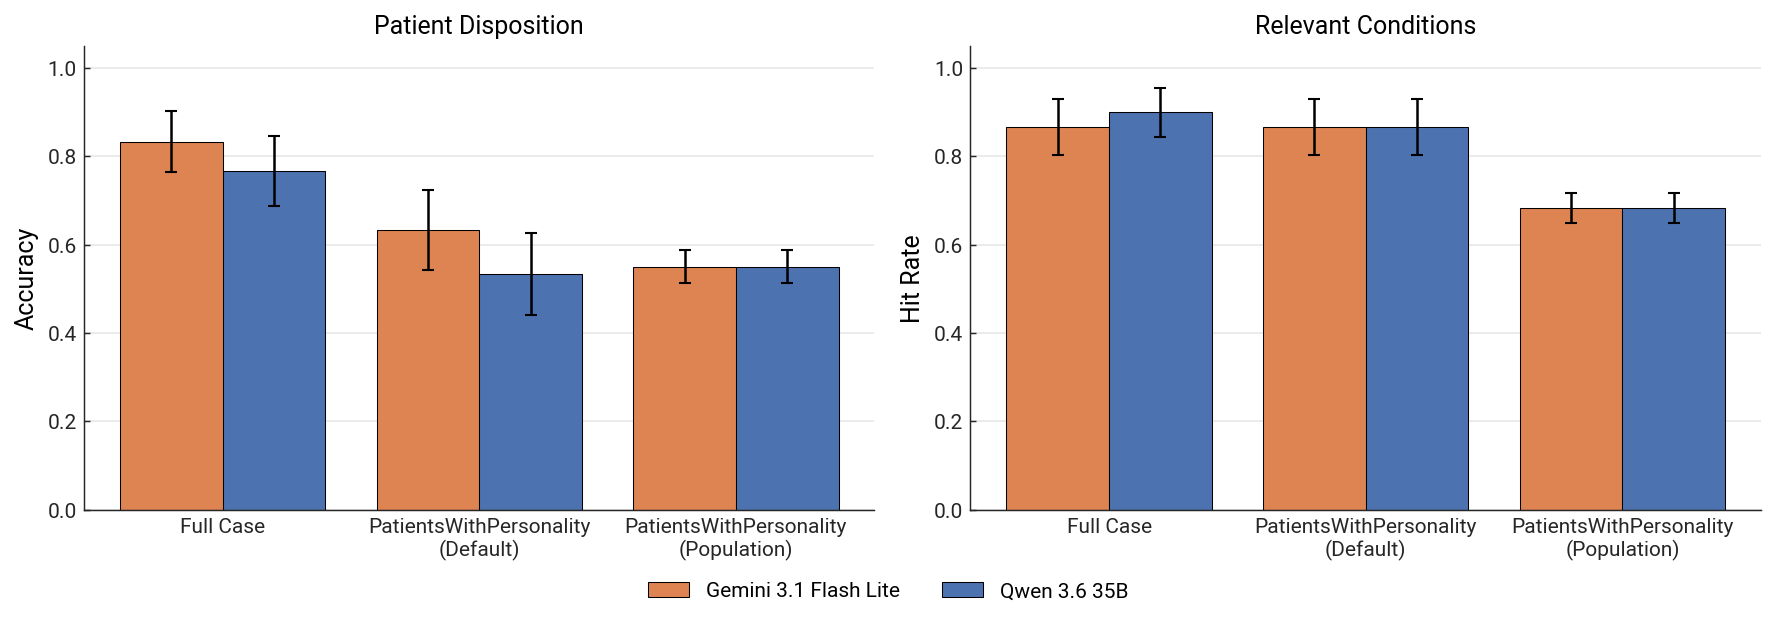

In [11]:
model_display_names = {
    "gemini-3.1-flash-lite-preview": "Gemini 3.1 Flash Lite",
    "qwen-3.6-35b-a3b": "Qwen 3.6 35B",
    # "openai/gpt-4o": "GPT-4o",
}

plot_helpmed_target_performance(
    df=df[df["assistant_model"].isin(model_display_names.keys())],
    target_cols=target_cols,
    patient_col="patient_group",
    patient_order=[
        "Full Case",
        "PatientsWithPersonality\n(Default)",
        "PatientsWithPersonality\n(Population)",
        "PatientSim\n(Default)",
        "CraftMD",
    ],
    target_display_names=target_display_names,
    model_display_names=model_display_names,
    palette=model_palette,
    x_label=[
        "Full Case",
        "PatientsWithPersonality\n(Default)",
        "PatientsWithPersonality\n(Population)",
        "PatientSim\n(Default)",
        "CraftMD",
    ],
    figure_size=(12, 4),
    xtick_rotation=0,
    y_label=target_y_labels,
    subplot_by="target",
    plot_type="bar",
    errtype="sem",
    save_as="benchmark_performance_agg",
);

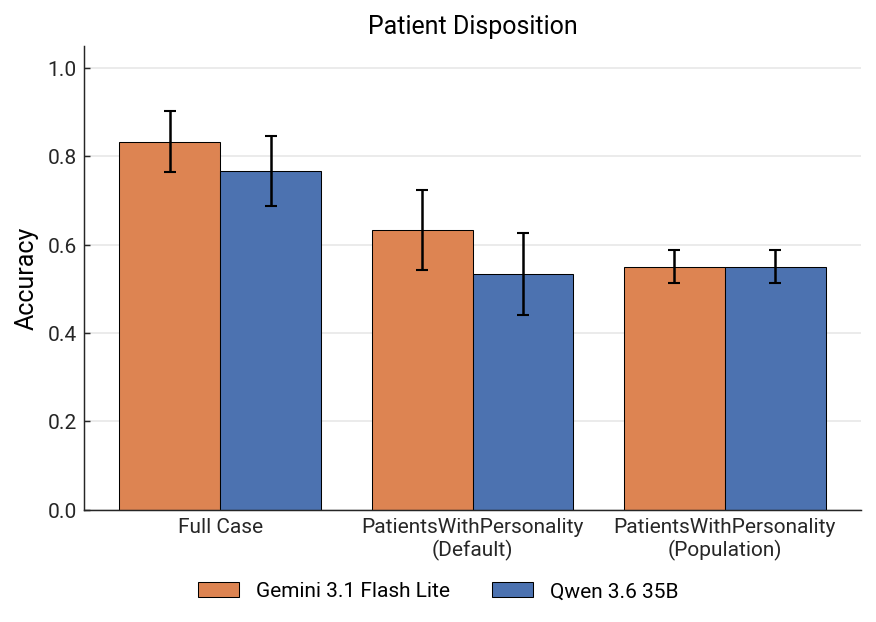

In [12]:
model_display_names = {
    "gemini-3.1-flash-lite-preview": "Gemini 3.1 Flash Lite",
    "qwen-3.6-35b-a3b": "Qwen 3.6 35B",
    # "openai/gpt-4o": "GPT-4o",
}

plot_helpmed_target_performance(
    df=df[df["assistant_model"].isin(model_display_names.keys())],
    target_cols=["disposition_correct"],
    patient_col="patient_group",
    patient_order=[
        "Full Case",
        "PatientsWithPersonality\n(Default)",
        "PatientsWithPersonality\n(Population)",
    ],
    target_display_names=target_display_names,
    model_display_names=model_display_names,
    palette=model_palette,
    x_label=[
        "Full Case",
        "PatientsWithPersonality\n(Default)",
        "PatientsWithPersonality\n(Population)",
    ],
    figure_size=(6, 4),
    xtick_rotation=0,
    y_label=target_y_labels,
    subplot_by="target",
    plot_type="bar",
    errtype="sem",
    save_as="benchmark_performance_agg_red",
);

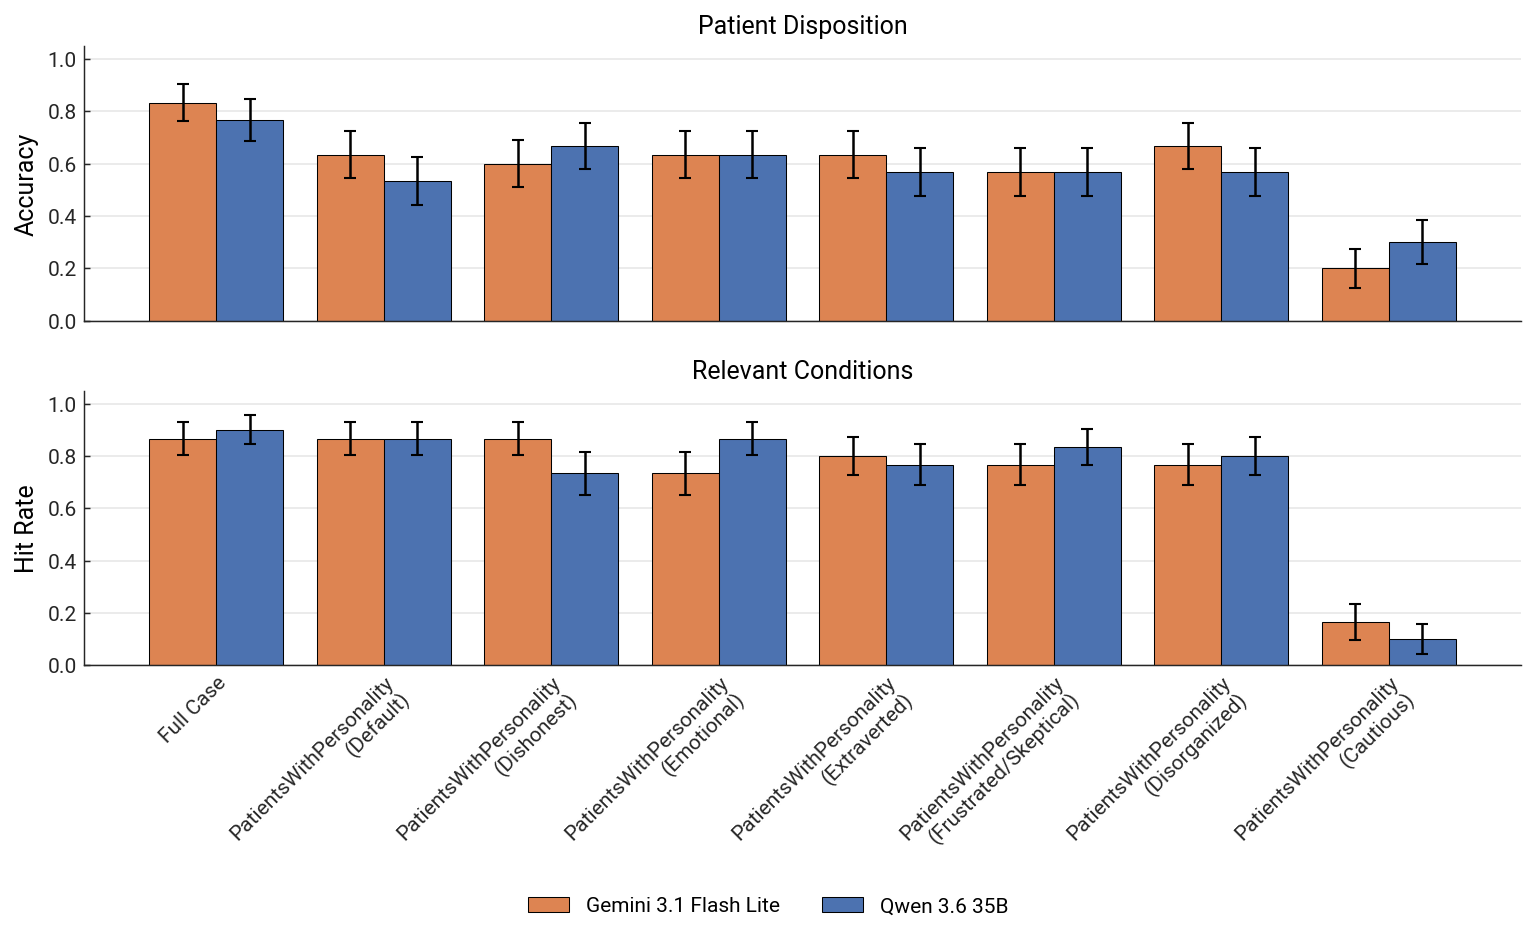

In [12]:
patient_order_pwp = [
    "Full Case",
    "PatientsWithPersonality\n(Default)",
    "PatientsWithPersonality\n(Dishonest)",
    "PatientsWithPersonality\n(Emotional)",
    "PatientsWithPersonality\n(Extraverted)",
    "PatientsWithPersonality\n(Frustrated/Skeptical)",
    "PatientsWithPersonality\n(Disorganized)",
    "PatientsWithPersonality\n(Cautious)",
]

plot_helpmed_target_performance(
    df=df[df["assistant_model"].isin(model_display_names.keys())],
    target_cols=target_cols,
    patient_col="patient_disp_name",
    patient_order=patient_order_pwp,
    target_display_names=target_display_names,
    model_display_names=model_display_names,
    palette=model_palette,
    x_label=patient_order_pwp,
    y_label=target_y_labels,
    subplot_by="target",
    plot_type="bar",
    errtype="sem",
    orientation="vertical",
    save_as="benchmark_performance_detailed",
);

In [13]:
def _resolve_patient_color(name):
    if name == "Full Case":
        return PATIENT_TYPE_PALETTE["BaselinePatient"]
    base = name.split(" (")[0]
    if base == "PatientsWithPersonality\n":
        return PATIENT_TYPE_PALETTE["PatientsWithPersonality\n (Ours)"]
    if base == "PatientSim":
        return PATIENT_TYPE_PALETTE["PatientSimPatient"]
    return PATIENT_TYPE_PALETTE[f"{base}Patient"]


patient_palette = {p: _resolve_patient_color(p) for p in patient_order}

fixed_model = "openai/gpt-4o"

plot_helpmed_target_performance(
    df=df[df["assistant_model"] == fixed_model],
    target_cols=target_cols,
    patient_col="patient_group",
    patient_order=patient_order,
    target_display_names=target_display_names,
    model_display_names=model_display_names,
    palette=patient_palette,
    x_label=patient_order,
    y_label=target_y_labels,
    subplot_by="target",
    plot_type="bar",
    errtype="sem",
    color_by="x",
    save_as="benchmark_performance_by_patient_type",
);

KeyError: 'BaselinePatient'